# Segmentación de clientes con K-Means

En este documento puedes desarrollar el eunciado adjunto (contiene algunas pistas y preguntas adicionales)

## Objetivos
- Comprender qué es clustering.
- Aplicar K-Means.
- Elegir el número óptimo de clusters.
- Interpretar los resultados.

## Pregunta Inicial
**¿Podemos identificar tipos de clientes según su comportamiento?**

## Descripción de las columnas
- **CustomerID**: Identificador único de cada cliente. No es relevante para el clustering, ya que no aporta información útil para la segmentación.
- **Genre**: Género del cliente (Male/Female). En algunos casos puede ser útil si se convierte a valores numéricos, aunque K-Means trabaja mejor con variables numéricas continuas.
- **Age**: Edad del cliente. Puede ser un factor clave en la segmentación, ya que distintos grupos de edad pueden tener diferentes patrones de gasto.
- **Annual Income (k$)**: Ingreso anual del cliente en miles de dólares. Es un indicador relevante para clasificar clientes en función de su poder adquisitivo.
- **Spending Score (1-100)**: Puntuación asignada a cada cliente según sus hábitos de gasto y comportamiento de compra (por ejemplo, un puntaje alto puede indicar que el cliente gasta mucho en relación con su ingreso).

## 1. Carga de datos

In [2]:

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ClientesCentroComercial.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. Exploración inicial

In [3]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:

df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [9]:
df.corr(numeric_only=True)["Age"].abs().sort_values(ascending=False)[1:]

Spending Score (1-100)    0.327227
CustomerID                0.026763
Annual Income (k$)        0.012398
Name: Age, dtype: float64

## Cuestiones
1. ¿Qué variables te parecen más útiles para agrupar clientes?
    -   Las variables que me parecen mas utiles son el genero, edad, puntuacion de lo gastado y el ingreso anual. Con estas variables podemos 
        agrupar los clientes en funcion de su gasto.

2. ¿Hay alguna variable que no tenga sentido usar?
    -   La variable CustomerID no tiene sentido que la usemos ya que no nos aporta nada relevante para poder agrupar los datos, ya que 
        solo es un identificador.

## 3. Selección de variables

Vamos a trabajar con dos variables especialmente útiles para segmentar clientes:
- **Annual Income (k$)**
- **Spending Score (1-100)**

In [5]:

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


**Recuerda:** estamos usando variables relacionadas con capacidad económica y comportamiento de compra.

## 4. Visualización inicial

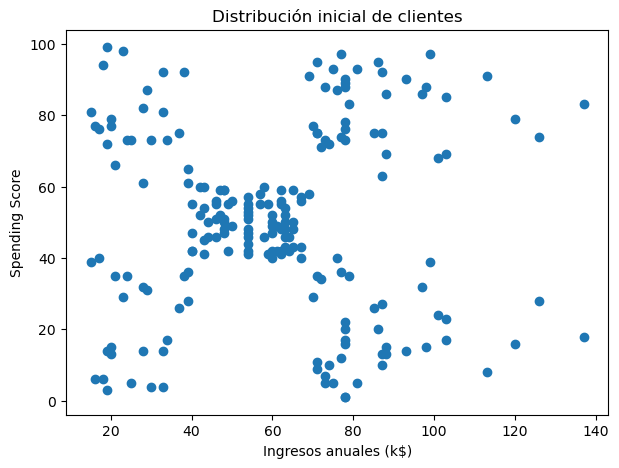

In [6]:

plt.figure(figsize=(7,5))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1])
plt.xlabel("Ingresos anuales (k$)")
plt.ylabel("Spending Score")
plt.title("Distribución inicial de clientes")
plt.show()

## Cuestión
**¿Observas posibles grupos de clientes a simple vista?**
-   Podemos distinguir cinco posibles grupos como: clientes que ingresan poco y gastan mucho, clientes que ingresan poco y gastan poco,
    clientes que ingresan medio y gastan medio, clientes que ingresan mucho y gastan mucho, y clientes que ingresan mucho y gastan poco.

## 5. Escalado de datos

**Importante:** K-Means utiliza distancias.  
Por eso, antes de aplicar el algoritmo, conviene poner las variables en la misma escala.

In [10]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# COMPLETAR
X_scaled = scaler.fit_transform(X)


## 6. Método del codo

Ahora vamos a probar distintos valores de **K** para decidir cuántos clusters conviene usar.

In [11]:

from sklearn.cluster import KMeans

inercia = []

for k in range(1, 11):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)

    # COMPLETAR
    modelo.fit(X_scaled)

    inercia.append(modelo.inertia_)

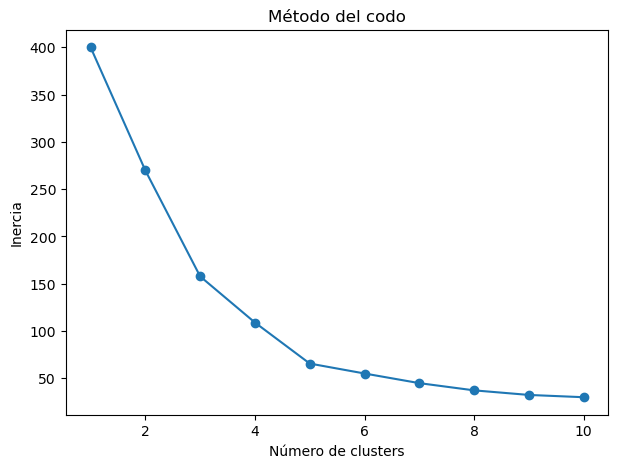

In [12]:

plt.figure(figsize=(7,5))
plt.plot(range(1, 11), inercia, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()

## Cuestiones
1. ¿En qué valor de **K** parece producirse el “codo”?
    -   El valor de k donde se produce el codo, seria en k=5 ya que a partir de 5 la mejora es minima lo que nos indica que
        a partir de ese valor, la precision del modelo no aumento significativamente.

2. ¿Por qué ese punto puede considerarse un buen compromiso?
    -   Porque a partir de k=5, la precision del modelo no mejora respecto a los anteriores valores, por lo tanto podriamos decir que
        en ese punto es donde se produce el "codo".


## 7. Aplicación de K-Means

In [14]:

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# COMPLETAR
clusters = kmeans.fit_predict(X_scaled)

## 8. Visualización de clusters

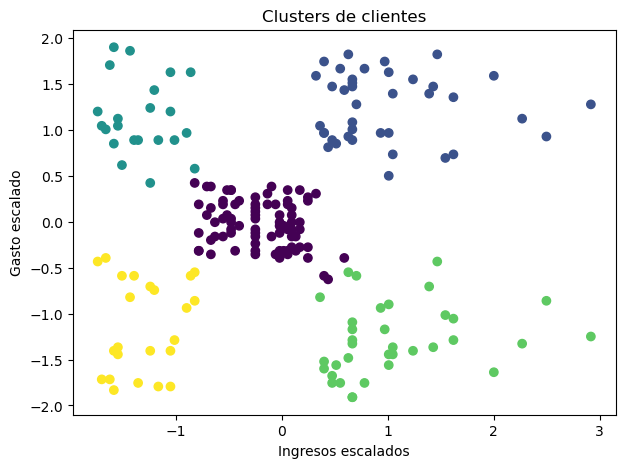

In [15]:

plt.figure(figsize=(7,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.xlabel("Ingresos escalados")
plt.ylabel("Gasto escalado")
plt.title("Clusters de clientes")
plt.show()

## 9. Centroides

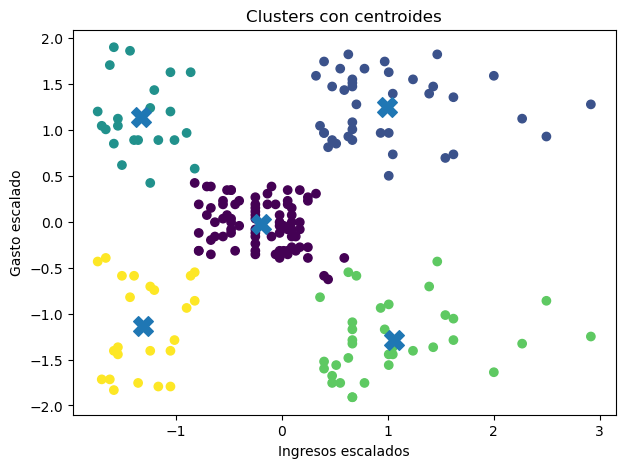

In [16]:

centroides = kmeans.cluster_centers_

plt.figure(figsize=(7,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.scatter(centroides[:, 0], centroides[:, 1], marker="X", s=200)
plt.xlabel("Ingresos escalados")
plt.ylabel("Gasto escalado")
plt.title("Clusters con centroides")
plt.show()

## 10. Interpretación de resultados

Añade una nueva columna al DataFrame con el cluster asignado a cada cliente.

In [17]:

# COMPLETAR
df["cluster"] = kmeans.labels_
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [18]:

df.groupby("cluster")[["Annual Income (k$)", "Spending Score (1-100)"]].mean()

,Annual Income (k$),Spending Score (1-100)
cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


## Cuestiones
1. ¿Qué tipo de clientes representa cada cluster?
    -   Cluster 0: clientes que ganan medio y gastan medio. 
    -   Cluster 1: clientes que ganan mucho y gastan mucho.
    -   Cluster 2: clientes que ganan poco y gastan mucho.
    -   Cluster 3: clientes que ganan mucho y gastan poco.
    -   Cluster 4: clientes que ganan poco y gastan poco.

2. ¿Cuál te parece más interesante para el negocio?
    -   Lo mas interesante para el negocio seria lo que gasta cada cliente, dejando de lado el ingreso ya que puede haber clientes que 
        ganan mucho y gastan poco y al contrario.

3. ¿Qué estrategia comercial podría aplicarse a cada grupo?
    -   

4. ¿Qué pasaría si no hubiéramos escalado los datos?
    -   Para usar K-Means deberiamos siempre escalar los datos ya que se basan en distancias, entonces el rango de las variables tendria que ser el 
        mismo para que las distancias sean reales.

5. ¿K-Means siempre encuentra los mejores grupos?
    -   No siempre encuentra los mejores grupos ya que debemos indicarle el numero de clusters en los que va a dividir los datos, tambien incluye los 
        outliers a un grupo lo que puede distorsionar los datos de agrupamiento como la media de los gastos o ingresos de cada grupo.

6. ¿Qué limitaciones tiene este algoritmo?
    -   Agrupar todos los valores a un grupo, incluso los outliers que no nos aportan nada.


## 11. Opcional

Prueba a repetir el análisis añadiendo la variable **Age**.

Preguntas:
- ¿Cambian los clusters?
    -   Si cambian los cluesters, respecto a la representacion grafica, podemos observar que al tener tres dimensiones, algunos clusters se superponen.
        Aunque realmente solo un cluster cambia significativamente respecto a los demas.

- ¿Son más realistas o más difíciles de interpretar?
    -   Son mas dificiles de interpretar siguiendo la representacion grafica ya que al tener tres dimesiones, carece de sentido representar los
        datos en una grafica ya que no somos capaces de distinguir a simple vista los grupos.

In [32]:
X_opcional = df[["Annual Income (k$)", "Spending Score (1-100)", "Age"]]
X_opcional.head()

,Annual Income (k$),Spending Score (1-100),Age
0,15,39,19
1,15,81,21
2,16,6,20
3,16,77,23
4,17,40,31


In [ ]:
scaler = StandardScaler()
X_opcional = scaler.fit_transform(X_opcional)

In [38]:

from sklearn.cluster import KMeans

inercia = []

for k in range(1, 11):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(X_opcional)
    inercia.append(modelo.inertia_)

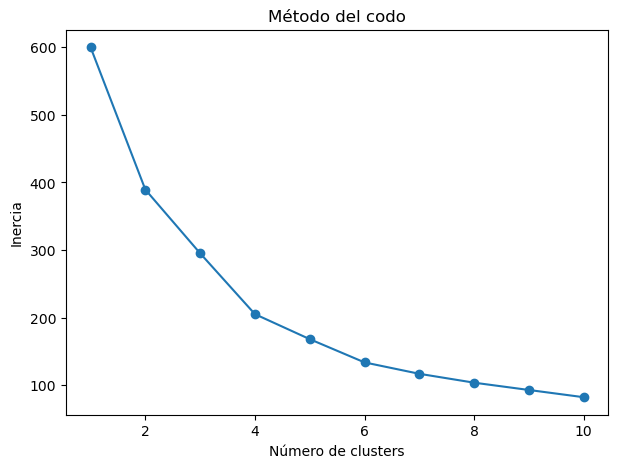

In [39]:
plt.figure(figsize=(7,5))
plt.plot(range(1, 11), inercia, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()

In [ ]:

kmeans_opcional = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters_opcional = kmeans_opcional.fit_predict(X_opcional)

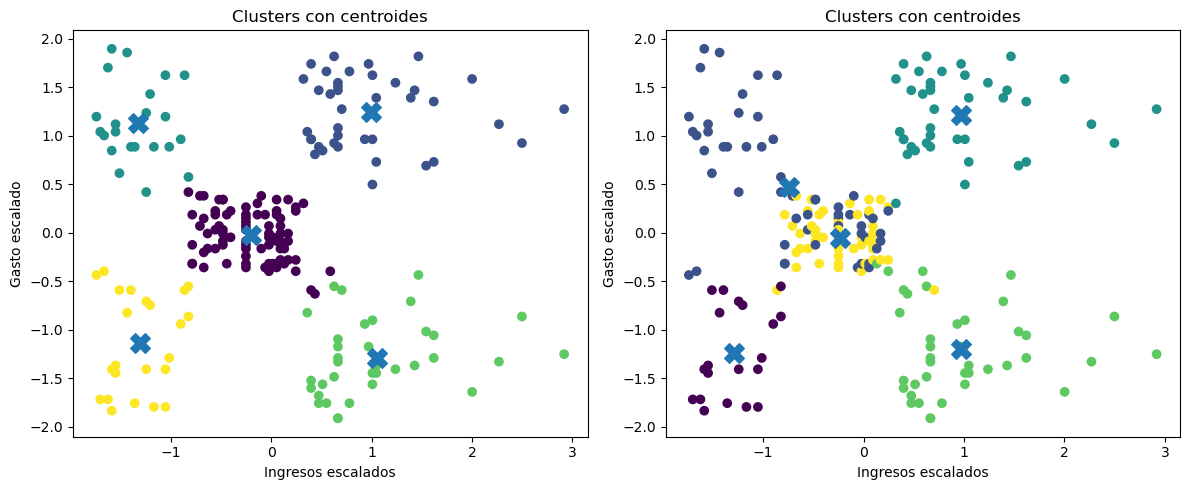

In [ ]:
centroides = kmeans.cluster_centers_

plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.scatter(centroides[:, 0], centroides[:, 1], marker="X", s=200)
plt.xlabel("Ingresos escalados")
plt.ylabel("Gasto escalado")
plt.title("Clusters con centroides")

centroides_opcional = kmeans_opcional.cluster_centers_

plt.subplot(1, 2, 2)
plt.scatter(X_opcional[:, 0], X_opcional[:, 1], c=clusters_opcional)
plt.scatter(centroides_opcional[:, 0], centroides_opcional[:, 1], marker="X", s=200)
plt.xlabel("Ingresos escalados")
plt.ylabel("Gasto escalado")
plt.title("Clusters con centroides")
plt.tight_layout()
plt.show()